In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def plot_runtime_by_simulation(df, ax=None, xlabel="Simulation", ylabel="Total_Runtime(m)"):
    if ax is None: _, ax = plt.subplots(figsize=(7,5))
    df[ylabel] = pd.to_numeric(df[ylabel], errors="coerce")

    sns.barplot(data=df, x=xlabel, y=ylabel, color="tab:blue", edgecolor=None, errorbar="sd", capsize=0.5, err_kws={"lw": 1.0}, ax=ax)

    ax.set_xlabel(xlabel, fontsize=14, labelpad=10)
    ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    ax.set_ylabel(ylabel, fontsize=14, labelpad=10)
    ax.tick_params(axis="x", labelrotation=90, labelsize=8)
    ax.tick_params(axis="y", labelsize=12)
    ax.margins(x=0.01)
    plt.tight_layout()
    return ax

In [5]:
def parse_time_to_sec_per_mcmc(s):
    h = 0
    m = 0
    sec = 0
    time = s.replace('/Msamples', '').strip()
    if "h" in time:
        h_part, time = time.split("h")
        h = int(h_part)
        time = time.split("h")[-1]
    if "m" in time:
        m_part, time = time.split("m")
        m = int(m_part)
        time = time.split("m")[-1]
    if "s" in time:
        sec_part = time.replace("s", "").strip()
        sec = int(sec_part)

    total_sec = h*3600 + m*60 + sec
    return total_sec / 1000000

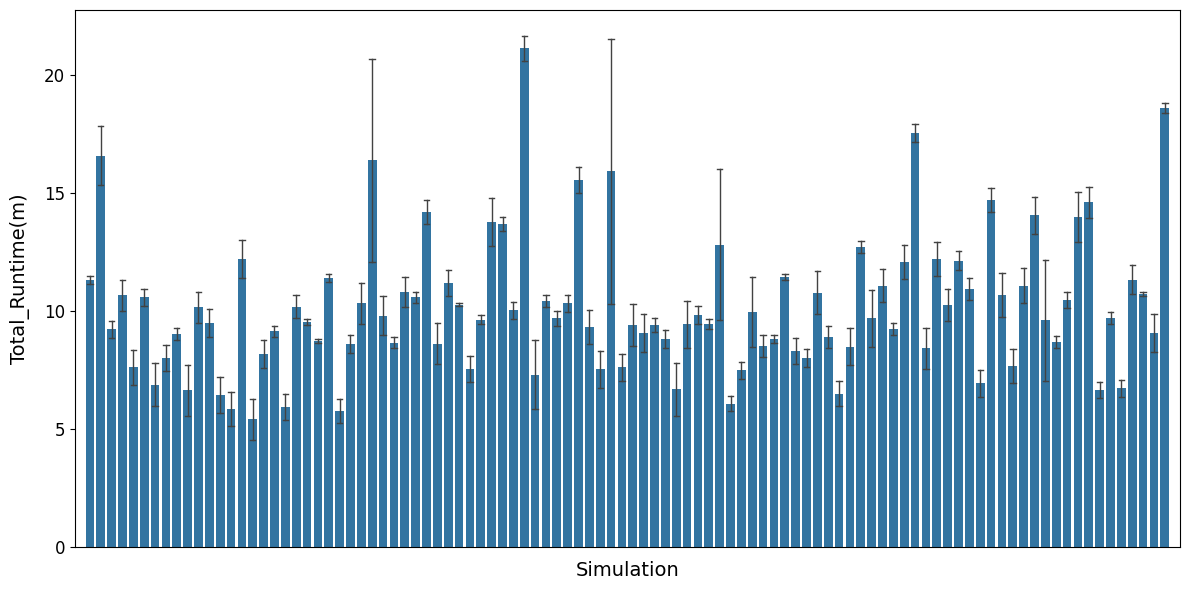

In [7]:
# Plot ideal sims data as a barplot
# Here all runs completed successfully and converged, so no need to recalculate runtimes or filter out terminal numbers
infile="/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/uniform_50cells_50sites_0.0025mut_10-6mig_data_8_24_24/beam_gtr_runtimes_11_7_25/all_times.txt"
df = pd.read_csv(infile, sep="\t")

df["sec_per_mcmc"] = df["Time_per_MCMC_Sample(s)"].apply(parse_time_to_sec_per_mcmc)
df["Total_Runtime(m)"] = df["sec_per_mcmc"] * df["Num_MCMC_Samples"] / 60.0

fig, ax = plt.subplots(figsize=(12,6))
plot_runtime_by_simulation(df, ax=ax)
plt.savefig(infile.replace(".txt", ".pdf"))
plt.show()
plt.close()

In [ ]:
def plot_runtime_by_num_tips(df, ax=None, xlabel="Num_Tips", ylabel="Total_Runtime(h)"):
    if ax is None: _, ax = plt.subplots(figsize=(7,5))
    df[ylabel] = pd.to_numeric(df[ylabel], errors="coerce")
    df[xlabel] = pd.to_numeric(df[xlabel], errors="coerce")

    sns.scatterplot(
        data=df, x=xlabel, y=df[ylabel],
        color="tab:blue", s=60,
        edgecolor=None, legend=False, ax=ax
    )

    ax.ticklabel_format(style="plain", axis="y")
    ax.set_xlabel(xlabel, fontsize=14, labelpad=10)
    ax.set_ylabel("Runtime (hours)", fontsize=14, labelpad=10)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.margins(x=0.02)
    plt.tight_layout()
    return ax

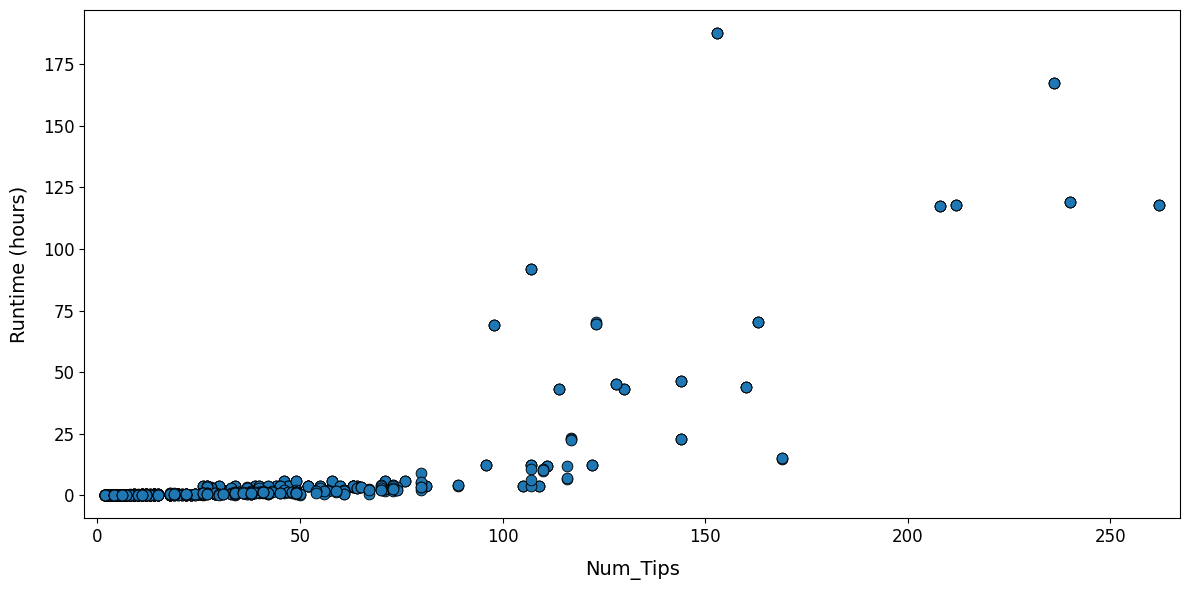

In [9]:
# Plot Quinn 2021 lung cancer data and Serio 2024 prostat cancer data runtimes
# Here we will re-calculate the total runtimes since some runs were stopped early, so total runtime output from beast2 is not in the log files
quinn_infile="/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/quinn_2021_lung_cancer_data/beam_gtr_runtimes_11_7_25/all_times.txt"
quinn_df = pd.read_csv(quinn_infile, sep="\t")
# Exclude quinn cps not analyzed by beam
excluded_cps_5k_by_original_paper = ["5", "16", "18", "25", "33", "38", "39", "41", "50", "53", "65", "69", "75", "81", "87", "88", "93"]
excluded_cps_5k_with_one_tissue = ["22", "29", "46", "48", "49", "78", "85", "94", "96"]
excluded_cps_5k_by_compute_requirements = ["1", "2", "3", "4", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "17", "19", "20", "21", "23", "27", "31"]
all_excluded_quinn = excluded_cps_5k_by_original_paper + excluded_cps_5k_with_one_tissue + excluded_cps_5k_by_compute_requirements
quinn_df = quinn_df[~quinn_df['cp_num'].astype(str).isin(all_excluded_quinn)]

serio_infile="/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/serio_prostate_cancer_data/beam_gtr_runtimes_11_7_25/all_times.txt"
serio_df = pd.read_csv(serio_infile, sep="\t")
# Exclude serio cps not analyzed by beam
excluded_by_size=["MMUS1875_CP01", "MMUS1466_CP01"]
excluded_by_one_tissue=[
    f"{mouse}_{cp}"
    for mouse, cps in {
        "MMUS1492": {"CP04", "CP06", "CP07", "CP09", "CP13"},
        "MMUS1588": {"CP10", "CP13", "CP19", "CP21"},
        "MMUS1469": {"CP096", "CP100", "CP084", "CP097", "CP123", "CP067", "CP116", "CP115", "CP114", "CP103", "CP093", "CP077"},
        "MMUS1457": {"CP30", "CP07", "CP33", "CP41", "CP43", "CP18", "CP19", "CP13", "CP28", "CP14", "CP29", "CP38", "CP24", "CP25", "CP11", "CP26", "CP12", "CP34", "CP36"},
        "MMUS1875": {"CP22", "CP09", "CP16", "CP12", "CP21"},
        "MMUS1495": {"CP096", "CP113", "CP108", "CP089", "CP086", "CP109", "CP095", "CP097", "CP104", "CP115"},
        "MMUS1466": {"CP22", "CP06", "CP17", "CP27", "CP15", "CP16", "CP24", "CP26", "CP20"},
        "MMUS1544": {"CP37", "CP84", "CP70", "CP85", "CP40", "CP55", "CP53", "CP68", "CP62", "CP79", "CP86", "CP60", "CP82", "CP36", "CP83"},
        "MMUS1874": {"CP22", "CP32", "CP07", "CP33", "CP18", "CP27", "CP28", "CP24", "CP26", "CP34", "CP20"},
        "MMUS1467": {"CP17", "CP27", "CP29", "CP15", "CP26", "CP12", "CP34", "CP35", "CP21"},
    }.items()
    for cp in cps
]
all_excluded_serio = excluded_by_size + excluded_by_one_tissue
serio_df = serio_df[~serio_df['cp_num'].astype(str).isin(all_excluded_serio)]

df=pd.concat([quinn_df, serio_df], ignore_index=True)

df['sec_per_mcmc'] = df['Time_per_MCMC_Sample(s)'].apply(parse_time_to_sec_per_mcmc)
df['Total_Runtime(h)'] = df['Num_MCMC_Samples'] * df['sec_per_mcmc'] / 3600.0

df['Num_Tips'] = pd.to_numeric(df['num_tips'], errors="coerce")

fig, ax = plt.subplots(figsize=(12,6))
plot_runtime_by_num_tips(df, ax=ax)
plt.savefig(quinn_infile.replace(".txt", "_runtime_vs_num_tips.pdf"))
plt.show()
plt.close()
